## Подготовка

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [107]:
data = pd.read_csv('data/r5_eda.csv')

In [108]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   int64  
 6   total_sulfur_dioxide  6497 non-null   int64  
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 609.2 KB


In [109]:
y = data['quality']
X = data.drop('quality', axis=1)

In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [112]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((5197, 11), (5197,), (1300, 11), (1300,))

In [113]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet

## Реализация пользовательских функций

In [114]:
import numpy as np

$ MAE=\frac{1}{m}{\sum_{i=1}^{m}|y_i-\hat{y}_i|} $

In [115]:
def mae_metrick(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

$ MSE=\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2} $

In [116]:
def mse_metrick(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

$ RMSE=\sqrt{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\hat{y}_i)^2}} $

In [117]:
def rmse_metrick(y_true, y_pred):
    return np.sqrt(mse_metrick(y_true, y_pred))

$ MAPE=\frac{1}{m}\sum_{i=1}^{m}{|\frac{y_i-\hat{y}_i}{y_i}|} $

In [118]:
def mape_metrick(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true))

$ R^2=\frac{MSE}{\frac{1}{m}{\sum_{i=1}^{m}(y_i-\bar{y})^2}} $. $\bar{y}$ - среднее значение целевого признака.

In [119]:
def r2_score_metrick(y_true, y_pred):
    denominator = np.sum((y_true - np.mean(y_true)) ** 2)
    numerator = mse_metrick(y_true, y_pred)
    return numerator / denominator

Вспомогательные

In [120]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

In [121]:
def sklearn_metrick_printer(y_true, y_pred):
    print(f'MAE: {mean_absolute_error(y_true, y_pred)}')
    print(f'MSE: {mean_squared_error(y_true, y_pred)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_true, y_pred))}')
    print(f'MAPE: {mean_absolute_percentage_error(y_true, y_pred)}')
    print(f'R^2: {r2_score(y_true, y_pred)}')

In [122]:
def metrick_printer(y_true, y_pred):
    print(f'MAE: {mae_metrick(y_true, y_pred)}')
    print(f'MSE: {mse_metrick(y_true, y_pred)}')
    print(f'RMSE: {rmse_metrick(y_true, y_pred)}')
    print(f'MAPE: {mape_metrick(y_true, y_pred)}')
    print(f'R^2: {r2_score_metrick(y_true, y_pred)}')

In [123]:
def return_metricks(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), sqrt(mean_squared_error(
        y_true, y_pred)), mean_absolute_percentage_error(y_true, y_pred), r2_score(y_true, y_pred)]

## Простая линейная регрессия

In [124]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)

### Метрики

In [125]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5527147413309352
MSE: 0.5098878497739079
RMSE: 0.7140643176730705
MAPE: 0.09636872683325413
R^2: 0.2926362944361317


In [126]:
metrick_printer(y_test, y_pred)

MAE: 0.5527147413309352
MSE: 0.5098878497739079
RMSE: 0.7140643176730705
MAPE: 0.09636872683325413
R^2: 0.0005441259273568218


In [127]:
len(lr.coef_)
lr.coef_

array([ 6.25358100e-02, -1.34326125e+00, -7.71618316e-02,  4.66533360e-02,
       -4.84521903e-01,  5.42104081e-03, -2.70619095e-03, -5.88968269e+01,
        4.31995165e-01,  8.01148146e-01,  2.57531967e-01])

## Линейная регрессия с L1-регуляризацией

In [128]:
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
y_pred = lasso.predict(X_test)

### Метрики

In [129]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6631839058560106
MSE: 0.7131071033307448
RMSE: 0.844456691210831
MAPE: 0.11615425706629168
R^2: 0.01071170199560112


In [130]:
metrick_printer(y_test, y_pred)

MAE: 0.6631839058560106
MSE: 0.7131071033307448
RMSE: 0.844456691210831
MAPE: 0.11615425706629168
R^2: 0.0007609909984649222


In [131]:
lasso.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00417326, -0.00154114, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

In [132]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
import numpy as np
import optuna

GridSearchCV

In [133]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]}

In [134]:
grid = GridSearchCV(Lasso(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10]},
             scoring='r2')

In [135]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.28366695328445846


RandomizedSearchCV

In [136]:
param_dist = {'alpha': np.logspace(-4, 1, 100)}

In [137]:
random_search = RandomizedSearchCV(
    Lasso(), param_dist, n_iter=20, cv=5, scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6.42807312e-04, 7.22080...
       6.89261210e-01, 7.74263683e-01, 8.69749003e-01, 9.77009957e-01,
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01])},
                   random_state=42, scoring='r2')

In [138]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.00015922827933410923
Best R^2: 0.283829949676206


Фреймворк Optuna

In [139]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    model = Lasso(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [140]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-04-25 11:00:17,732] A new study created in memory with name: no-name-4a3110ae-3d96-479b-be3c-b68a92ee9592
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-04-25 11:00:17,784] Trial 0 finished with value: 0.2836653224122826 and parameters: {'alpha': 0.0010203572875575253}. Best is trial 0 with value: 0.2836653224122826.
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\1532896469.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
[I 2025-04-25 11:00:17,825] Trial 1 finished with 

In [141]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00013938521174468714
Best R^2: 0.28383093133716547


Сравнение гиперпараметров

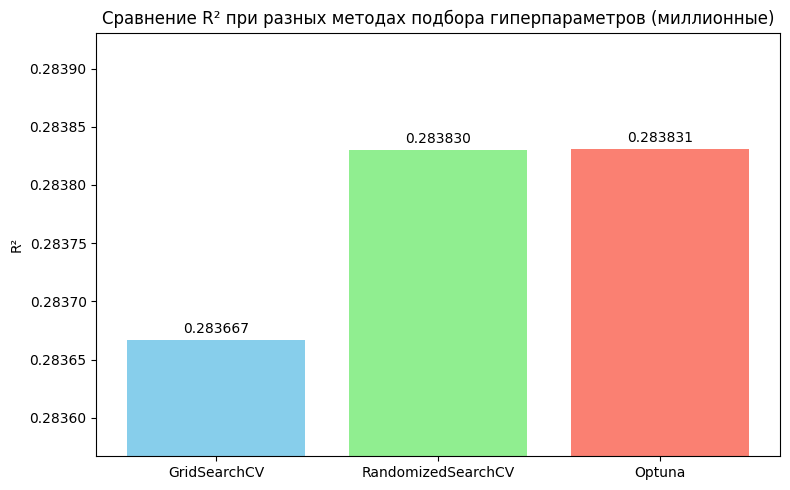

In [142]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [143]:
lasso_best = Lasso(alpha=0.0001).fit(X_train, y_train)
y_pred_new = lasso_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [144]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5550179796827185
MSE: 0.511499592336802
RMSE: 0.7151919968349771
MAPE: 0.09678543488177355
R^2: 0.2904003357008741


In [145]:
lasso_best.coef_

array([ 0.00167838, -1.4621334 , -0.0677035 ,  0.02512398, -0.68562681,
        0.00535763, -0.0024396 , -0.        ,  0.14074683,  0.65573836,
        0.32791244])

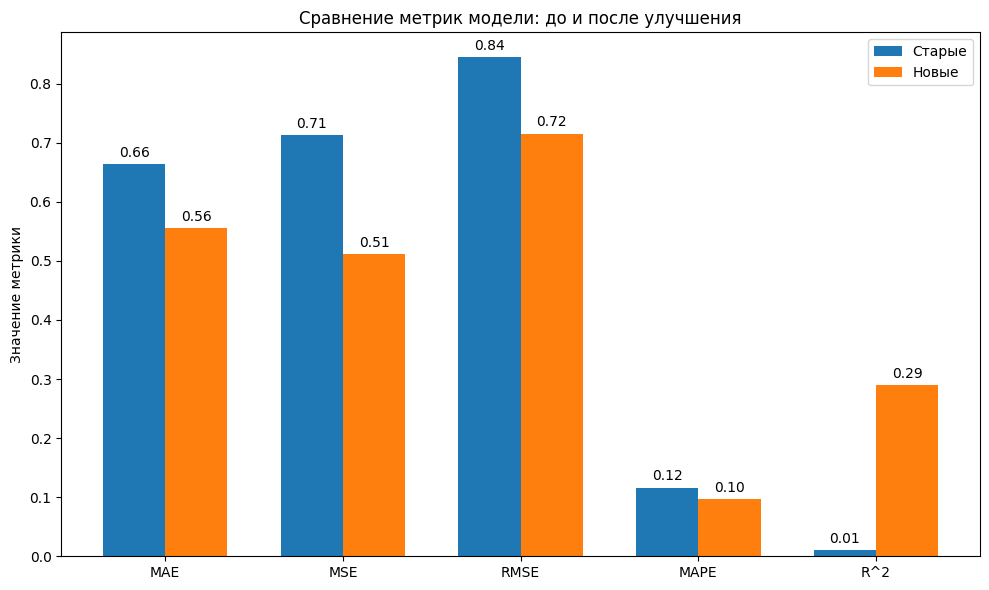

In [146]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<Axes: xlabel='quality', ylabel='Density'>

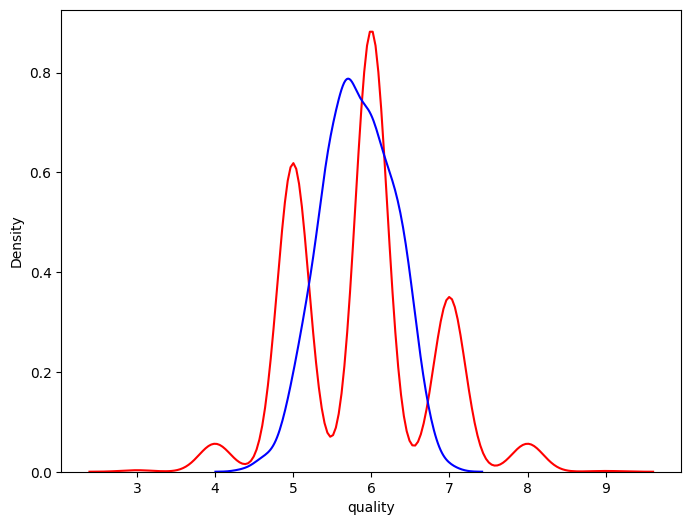

In [147]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с L2-регуляризацией

In [148]:
ridge = Ridge(alpha=0.5).fit(X_train, y_train)
y_pred = ridge.predict(X_test)

### Метрики

In [149]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5549110714749768
MSE: 0.5114055860252374
RMSE: 0.7151262727835116
MAPE: 0.0967655474766237
R^2: 0.29053074997319706


In [150]:
metrick_printer(y_test, y_pred)

MAE: 0.5549110714749768
MSE: 0.5114055860252374
RMSE: 0.7151262727835116
MAPE: 0.0967655474766237
R^2: 0.0005457455769436946


In [151]:
len(ridge.coef_)
ridge.coef_

array([ 0.00254925, -1.46019986, -0.07271154,  0.02526568, -0.72216455,
        0.00536093, -0.00243701, -0.31406467,  0.14545731,  0.66010779,
        0.32741236])

### Подбор гиперпараметров

GridSearchCV

In [152]:
param_grid = {'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]}

In [153]:
grid = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [0.001, 0.01, 0.1, 0.5, 1, 10, 100]},
             scoring='r2')

In [154]:
print("Best alpha:", grid.best_params_['alpha'])
print("Best R^2:", grid.best_score_)

Best alpha: 0.001
Best R^2: 0.2854787312383766


RandomizedSearchCV

In [155]:
param_dist = {'alpha': np.logspace(-4, 2, 100)}

In [156]:
random_search = RandomizedSearchCV(Ridge(), param_distributions=param_dist, n_iter=20, cv=5,
                                   scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_iter=20,
                   param_distributions={'alpha': array([1.00000000e-04, 1.14975700e-04, 1.32194115e-04, 1.51991108e-04,
       1.74752840e-04, 2.00923300e-04, 2.31012970e-04, 2.65608778e-04,
       3.05385551e-04, 3.51119173e-04, 4.03701726e-04, 4.64158883e-04,
       5.33669923e-04, 6.13590727e-04, 7.05480231e-04, 8.11130831e-04,
       9.32603347e-04, 1.07226...
       4.03701726e+00, 4.64158883e+00, 5.33669923e+00, 6.13590727e+00,
       7.05480231e+00, 8.11130831e+00, 9.32603347e+00, 1.07226722e+01,
       1.23284674e+01, 1.41747416e+01, 1.62975083e+01, 1.87381742e+01,
       2.15443469e+01, 2.47707636e+01, 2.84803587e+01, 3.27454916e+01,
       3.76493581e+01, 4.32876128e+01, 4.97702356e+01, 5.72236766e+01,
       6.57933225e+01, 7.56463328e+01, 8.69749003e+01, 1.00000000e+02])},
                   random_state=42, scoring='r2')

In [157]:
print("Best alpha:", random_search.best_params_['alpha'])
print("Best R^2:", random_search.best_score_)

Best alpha: 0.0004037017258596554
Best R^2: 0.285565730805177


Фреймворк Optuna

In [158]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
    model = Ridge(alpha=alpha)
    score = cross_val_score(model, X_train, y_train, scoring='r2', cv=5).mean()
    return score

In [159]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2025-04-25 11:00:21,668] A new study created in memory with name: no-name-34d78120-b09d-4518-ab59-ce87b3491590
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-04-25 11:00:21,715] Trial 0 finished with value: 0.27363503373038667 and parameters: {'alpha': 53.29314729532089}. Best is trial 0 with value: 0.27363503373038667.
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\1837225706.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 100.0)
[I 2025-04-25 11:00:21,754] Trial 1 finished with 

In [160]:
print("Best alpha:", study.best_params['alpha'])
print("Best R^2:", study.best_value)

Best alpha: 0.00029890095889357576
Best R^2: 0.2855687325493313


Сравнение гиперпараметров

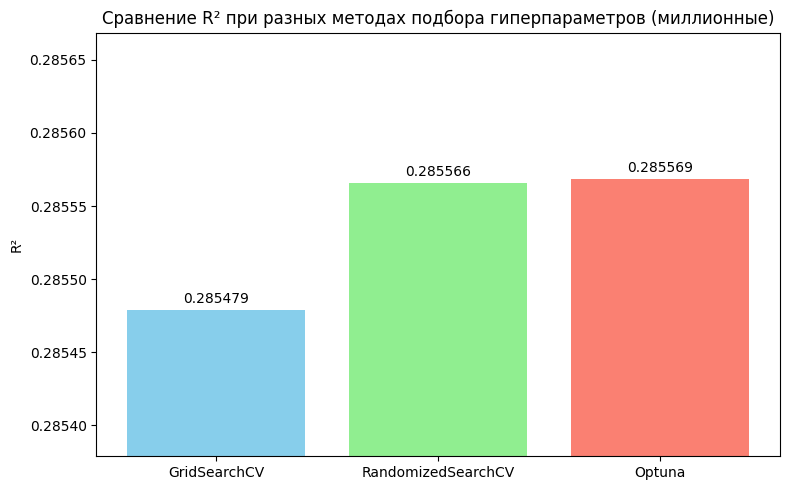

In [161]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [162]:
ridge_best = Ridge(alpha=0.0001).fit(X_train, y_train)
y_pred_new = ridge_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [163]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5527250613458808
MSE: 0.5098456373760779
RMSE: 0.7140347592212006
MAPE: 0.09637100225322584
R^2: 0.2926948553886294


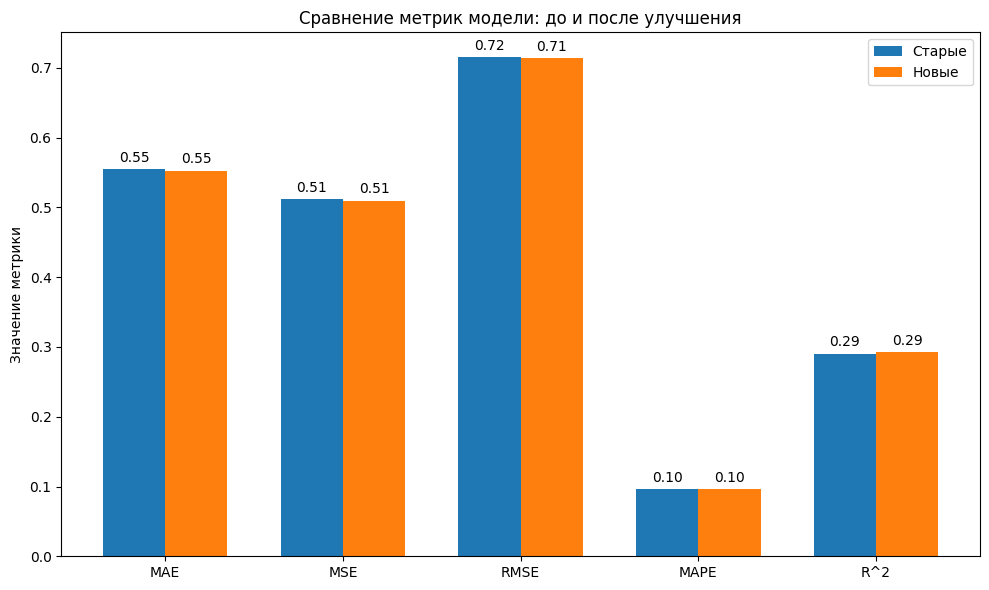

In [164]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<Axes: xlabel='quality', ylabel='Density'>

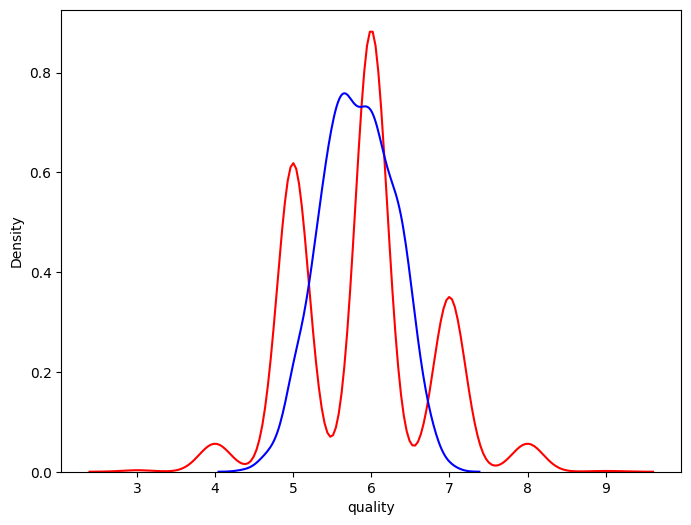

In [165]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Линейная регрессия с двумя регуляризаторами

In [166]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=1.0, l1_ratio=0.5)
base_elastic_model.fit(X_train, y_train)
y_pred = base_elastic_model.predict(X_test)

### Метрики

In [167]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.6632114793687657
MSE: 0.7131362665780985
RMSE: 0.8444739584961152
MAPE: 0.11615913788696475
R^2: 0.010671244034652472


In [168]:
metrick_printer(y_test, y_pred)

MAE: 0.6632114793687657
MSE: 0.7131362665780985
RMSE: 0.8444739584961152
MAPE: 0.11615913788696475
R^2: 0.0007610221199733443


In [169]:
len(base_elastic_model.coef_)
base_elastic_model.coef_

array([-0.        , -0.        ,  0.        , -0.        , -0.        ,
        0.00415841, -0.00153752, -0.        ,  0.        ,  0.        ,
        0.        ])

### Подбор гиперпараметров

GridSearchCV

In [170]:
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

In [171]:
grid = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    scoring='r2',
    cv=5
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=ElasticNet(max_iter=100000),
             param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10],
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

In [172]:
print("Best params:", grid.best_params_)
print("Best R^2:", grid.best_score_)

Best params: {'alpha': 0.001, 'l1_ratio': 0.1}
Best R^2: 0.2838040887644048


RandomizedSearchCV

In [173]:
param_dist = {
    'alpha': np.logspace(-4, 1, 100),
    'l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [174]:
random_search = RandomizedSearchCV(
    ElasticNet(max_iter=100000),
    param_distributions=param_dist,
    n_iter=30,
    scoring='r2',
    cv=5,
    random_state=42
)
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=ElasticNet(max_iter=100000), n_iter=30,
                   param_distributions={'alpha': array([1.00000000e-04, 1.12332403e-04, 1.26185688e-04, 1.41747416e-04,
       1.59228279e-04, 1.78864953e-04, 2.00923300e-04, 2.25701972e-04,
       2.53536449e-04, 2.84803587e-04, 3.19926714e-04, 3.59381366e-04,
       4.03701726e-04, 4.53487851e-04, 5.09413801e-04, 5.72236766e-04,
       6....
       1.09749877e+00, 1.23284674e+00, 1.38488637e+00, 1.55567614e+00,
       1.74752840e+00, 1.96304065e+00, 2.20513074e+00, 2.47707636e+00,
       2.78255940e+00, 3.12571585e+00, 3.51119173e+00, 3.94420606e+00,
       4.43062146e+00, 4.97702356e+00, 5.59081018e+00, 6.28029144e+00,
       7.05480231e+00, 7.92482898e+00, 8.90215085e+00, 1.00000000e+01]),
                                        'l1_ratio': array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])},
                   random_state=42, scoring='r2')

In [175]:
print("Best params:", random_search.best_params_)
print("Best R^2:", random_search.best_score_)

Best params: {'l1_ratio': np.float64(0.1), 'alpha': np.float64(0.00025353644939701115)}
Best R^2: 0.28390982174631024


Фреймворк Optuna

In [176]:
def objective(trial):
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='r2').mean()
    return score

In [177]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

[I 2025-04-25 11:00:26,556] A new study created in memory with name: no-name-610a600f-bc5f-4ea5-b74c-677ca40b672a
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\4049124632.py:2: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\4049124632.py:3: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
[I 2025-04-25 11:00:26,608] Trial 0 finished with value: 0.09785142655334547 and parameters: {'alpha': 0.3868885081889082, 'l1_ratio': 0.8619391362267471}. Best is trial 0 with value: 0.09785142655334547.
C:\Users\vaiforic\AppData\Local\Temp

In [178]:
print("Best params:", study.best_params)
print("Best R^2:", study.best_value)

Best params: {'alpha': 0.0004149649785263496, 'l1_ratio': 0.13296752190672995}
Best R^2: 0.2839214442966715


Сравнение гиперпараметров

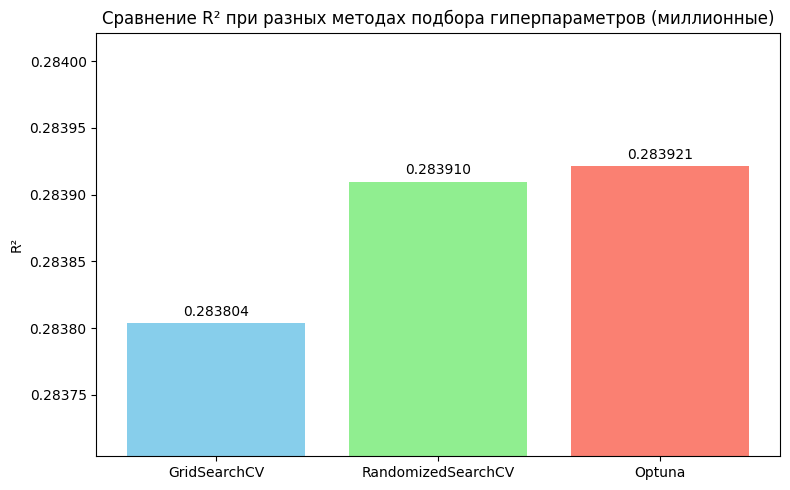

In [179]:
models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(models, r2_scores, color=[
              'skyblue', 'lightgreen', 'salmon'])

ax.set_ylabel('R²')
ax.set_title(
    'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

margin = 0.0001
y_min = min(r2_scores) - margin
y_max = max(r2_scores) + margin

ax.set_ylim(y_min, y_max)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.6f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Обучение с наилучшим гиперпараметром

In [180]:
base_elastic_model = ElasticNet(max_iter=100000, alpha=0.000253, l1_ratio=0.1)
base_elastic_model.fit(X_train, y_train)
y_pred_new = base_elastic_model.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [181]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5550382315044766
MSE: 0.5114321825769861
RMSE: 0.7151448682448796
MAPE: 0.09678742090541641
R^2: 0.29049385277039363


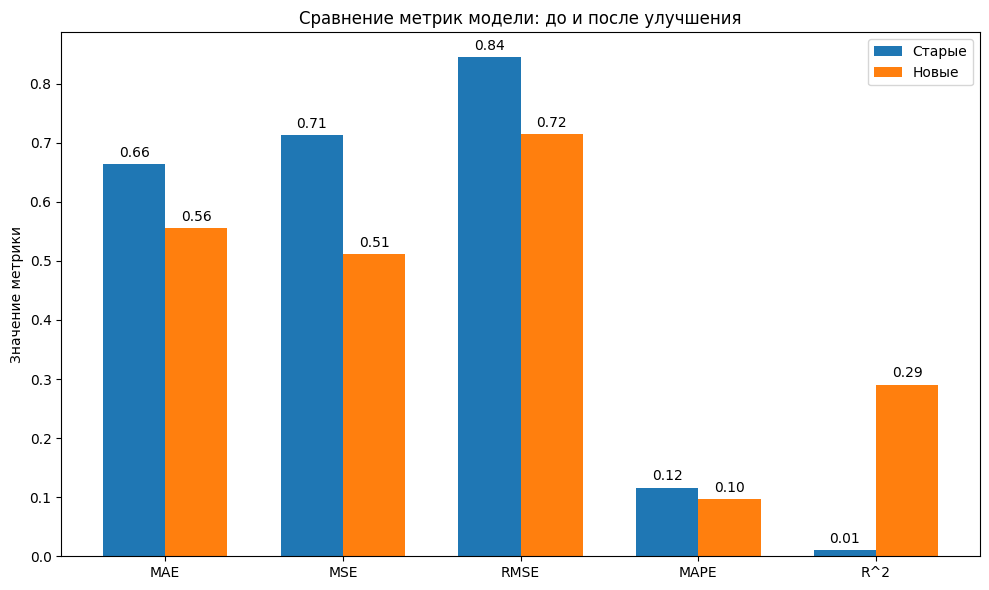

In [182]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<Axes: xlabel='quality', ylabel='Density'>

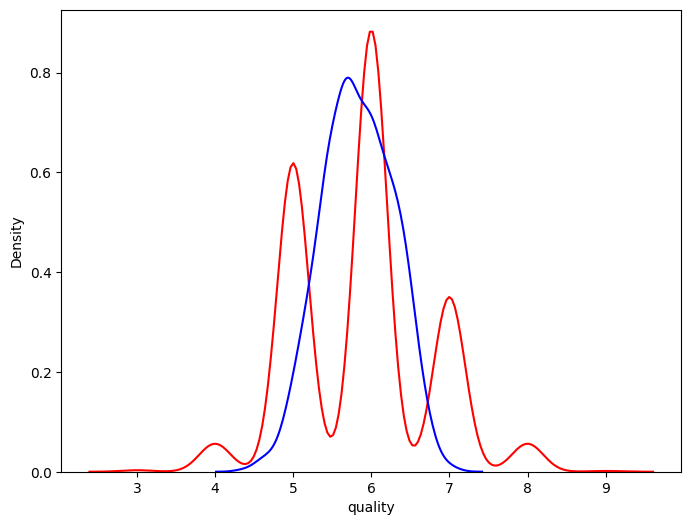

In [183]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Полиномиальная регрессия

In [184]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [185]:
polynomial_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])

In [186]:
polynomial_model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(include_bias=False)),
                ('scaler', StandardScaler()), ('reg', LinearRegression())])

In [187]:
y_pred = polynomial_model.predict(X_test)

### Метрики

In [188]:
sklearn_metrick_printer(y_test, y_pred)

MAE: 0.5431319592917387
MSE: 0.4946356070090285
RMSE: 0.7033033534748917
MAPE: 0.09479224800169712
R^2: 0.31379561989389415


In [189]:
metrick_printer(y_test, y_pred)

MAE: 0.5431319592917387
MSE: 0.4946356070090285
RMSE: 0.7033033534748917
MAPE: 0.09479224800169712
R^2: 0.0005278495231585429


In [190]:
polynomial_model.named_steps['reg'].coef_

array([-3.91357672e+01, -2.37271301e+01,  4.73642091e+01, -1.23737580e+02,
       -7.18065026e+01,  1.78335010e+00,  1.06585664e+02,  5.04432463e+01,
        4.93766232e+01,  8.17409399e+00,  3.71639666e+01, -7.57260257e-01,
       -1.20554851e-01,  5.19686741e-01, -8.50009021e-01, -9.81992590e-01,
        8.18780405e-02,  2.96279284e-01,  3.89693011e+01,  1.06424012e+00,
        3.39674369e-01,  2.23623223e-01,  5.66330508e-02,  3.50077790e-02,
       -2.26425653e-01,  1.13996421e-01, -1.64970524e-02,  1.24098470e-01,
        2.24836001e+01,  3.01469979e-01,  3.93450746e-02,  7.80267507e-01,
       -8.52750617e-02,  1.91309716e-01,  1.15584448e-01,  8.92939536e-02,
        3.76474962e-02, -4.86839612e+01,  8.70244407e-01, -6.18328240e-03,
       -1.96861910e-01, -9.35395807e-01, -3.40592712e-01, -8.85111326e-02,
        7.29934051e-01,  1.25635696e+02, -7.79626676e-01, -1.21368090e-01,
        1.18599001e+00, -8.93128054e-02,  2.56403070e-02, -3.39708592e-03,
        7.46303033e+01, -

### Подбор гиперпараметров

GridSearchCV

In [191]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures(include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', ElasticNet(max_iter=100000))
])

In [192]:
param_grid = {
    'poly__degree': [2, 3],
    'reg__alpha': [0.001, 0.01, 0.1, 1],
    'reg__l1_ratio': [0.2, 0.5, 0.8]
}

In [193]:
grid = GridSearchCV(pipeline, param_grid, cv=5, n_jobs=-1, scoring='r2')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('scaler', StandardScaler()),
                                       ('reg', ElasticNet(max_iter=100000))]),
             n_jobs=-1,
             param_grid={'poly__degree': [2, 3],
                         'reg__alpha': [0.001, 0.01, 0.1, 1],
                         'reg__l1_ratio': [0.2, 0.5, 0.8]},
             scoring='r2')

In [194]:
print("Best params:", grid.best_params_)
print("Best R^2:", grid.best_score_)

Best params: {'poly__degree': 3, 'reg__alpha': 0.001, 'reg__l1_ratio': 0.8}
Best R^2: 0.3351034669200071


RandomizedSearchCV

In [195]:
param_dist = {
    'poly__degree': [2, 3],
    'reg__alpha': np.logspace(-4, 1, 100),
    'reg__l1_ratio': np.linspace(0.1, 0.9, 9)
}

In [196]:
random_search = RandomizedSearchCV(
    pipeline, param_distributions=param_dist,
    n_iter=30, cv=5, n_jobs=-1, scoring='r2', random_state=42
)
random_search.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
print("Best params:", random_search.best_params_)
print("Best R^2:", random_search.best_score_)

Фреймворк Optuna

In [ ]:
def objective(trial):
    degree = trial.suggest_int('degree', 2, 3)
    alpha = trial.suggest_loguniform('alpha', 1e-4, 10.0)
    l1_ratio = trial.suggest_uniform('l1_ratio', 0.1, 0.9)

    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000))
    ])

    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    return score

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40, n_jobs=-1)

In [ ]:
print("Best params:", study.best_params)
print("Best R^2:", study.best_value)

Сравнение гиперпараметров

In [ ]:
# models = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

# r2_scores = [grid.best_score_, random_search.best_score_, study.best_value]

# fig, ax = plt.subplots(figsize=(8, 5))
# bars = ax.bar(models, r2_scores, color=[
#               'skyblue', 'lightgreen', 'salmon'])

# ax.set_ylabel('R²')
# ax.set_title(
#     'Сравнение R² при разных методах подбора гиперпараметров (миллионные)')

# margin = 0.0001
# y_min = min(r2_scores) - margin
# y_max = max(r2_scores) + margin

# ax.set_ylim(y_min, y_max)

# for bar in bars:
#     height = bar.get_height()
#     ax.annotate(f'{height:.6f}',
#                 xy=(bar.get_x() + bar.get_width() / 2, height),
#                 xytext=(0, 3),
#                 textcoords="offset points",
#                 ha='center', va='bottom')

# plt.tight_layout()
# plt.show()

### Обучение с наилучшим гиперпараметром

In [ ]:
polynomial_model_best = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
polynomial_model_best.fit(X_train, y_train)
y_pred_new = polynomial_model_best.predict(X_test)

### Метрики с наилучшим гиперпараметром

In [ ]:
sklearn_metrick_printer(y_test, y_pred_new)

MAE: 0.5591439807902187
MSE: 0.523325019566456
RMSE: 0.723412067611853
MAPE: 0.10174569169565086
R^2: 0.3332705494538195


In [ ]:
polynomial_model_best.named_steps['reg'].coef_

array([-4.78961650e+01, -2.04318359e+01,  4.86246700e+01, -1.24434839e+02,
       -6.17238090e+01,  2.22123764e+01,  9.29551274e+01,  7.67652994e+01,
        3.42975307e+01, -1.81826234e+01,  5.58500149e+01, -7.40818305e-01,
       -1.47621954e-01,  5.04851998e-01, -7.76748626e-01, -8.24666721e-01,
        9.63572290e-02,  2.97977063e-01,  4.79611852e+01,  8.14560836e-01,
        7.27570335e-02,  4.62264996e-01,  7.38424969e-02,  3.86347302e-02,
       -2.39313133e-01,  1.21373748e-01,  2.73939000e-02,  4.94083780e-02,
        1.95201814e+01,  8.61403145e-02,  2.67536271e-02,  6.87674172e-01,
       -1.16990973e-01,  1.90027485e-01,  9.91165121e-02,  1.19380383e-01,
       -2.77591785e-02, -4.96689967e+01,  6.74498396e-01, -6.42574847e-03,
       -1.97860493e-01, -1.05021557e+00, -2.89275726e-01,  1.87472134e-02,
        6.45952686e-01,  1.26505258e+02, -1.15055733e+00, -2.56569737e-01,
        1.51508467e+00, -5.59340312e-02,  1.75452815e-03, -1.06946930e-03,
        6.40904959e+01, -

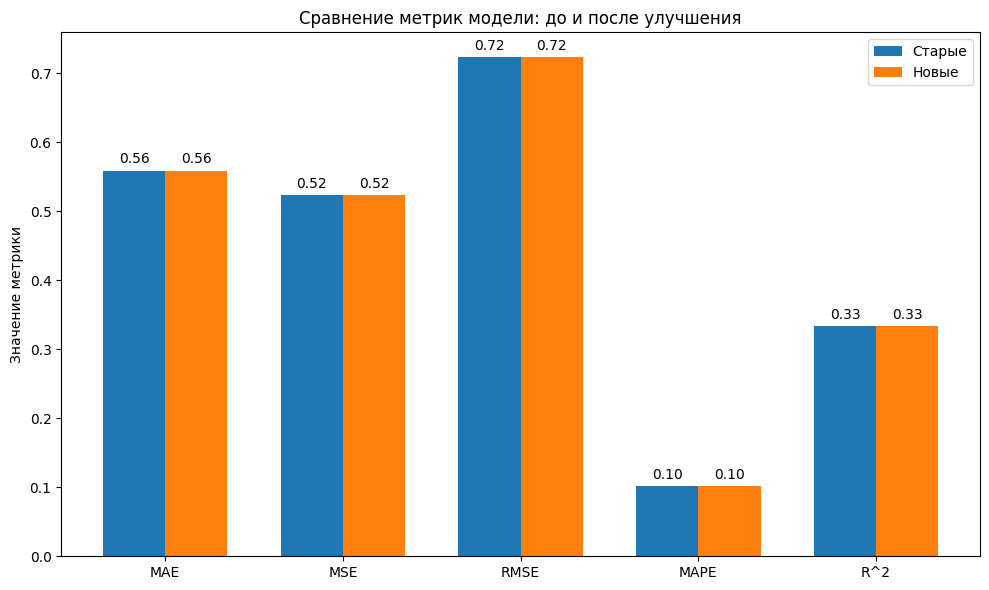

In [ ]:
metrics = ['MAE', 'MSE', 'RMSE', 'MAPE', 'R^2']

old_values = return_metricks(y_test, y_pred)

new_values = return_metricks(y_test, y_pred_new)

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, old_values, width, label='Старые')
bars2 = ax.bar(x + width/2, new_values, width, label='Новые')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение метрик модели: до и после улучшения')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')


add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
C:\Users\vaiforic\AppData\Local\Temp\ipykernel_19076\2118410706.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


<Axes: xlabel='quality', ylabel='Density'>

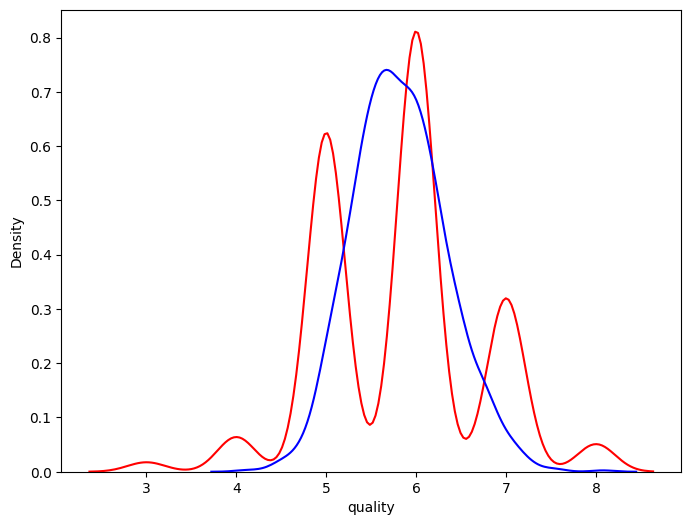

In [ ]:
plt.figure(figsize=(8, 6))

ax1 = sns.distplot(y_test, hist=False, color='Red', label='Actual weight')
sns.distplot(y_pred_new, hist=False, color='Blue',
             ax=ax1, label='Predicted weight')

## Влияние предикторов на целевой признак

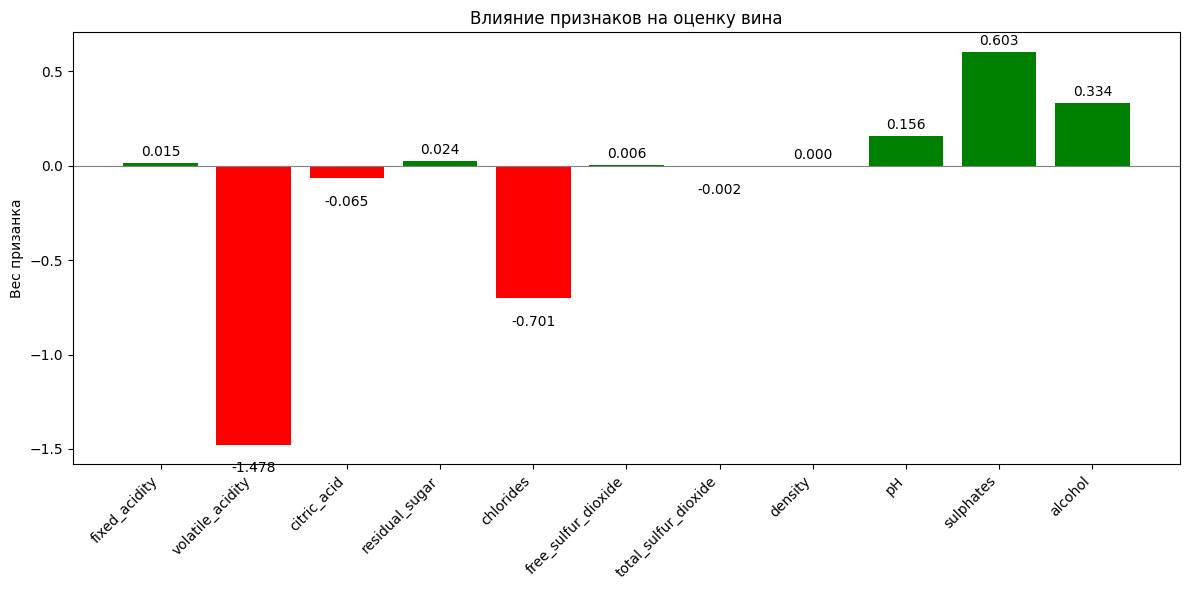

In [ ]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides",
    "free_sulfur_dioxide", "total_sulfur_dioxide", "density", "pH", "sulphates", "alcohol"
]
weights = np.array([
    0.01527086, -1.47784147, -0.06488792, 0.02390045, -0.70087447,
    0.00559915, -0.0024541, -0.0, 0.15563081, 0.6031466, 0.33379409
])

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(features, weights, color=np.where(weights >= 0, 'green', 'red'))

ax.set_title("Влияние признаков на оценку вина")
ax.set_ylabel("Вес призанка")
ax.axhline(0, color='gray', linewidth=0.8)

plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

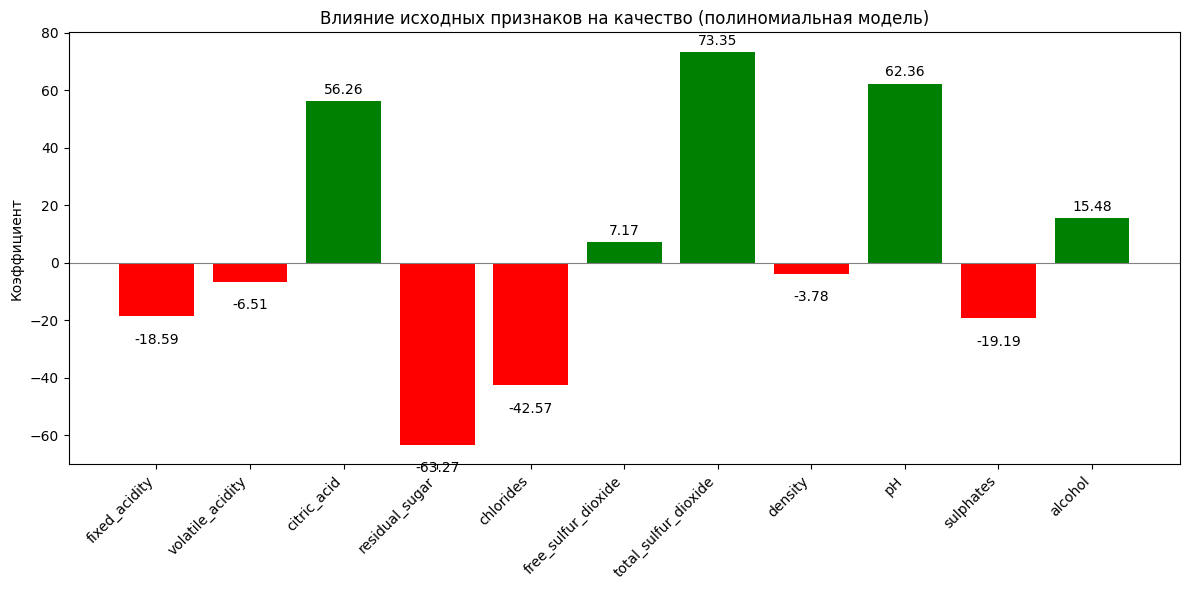

In [ ]:
features = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar", "chlorides",
    "free_sulfur_dioxide", "total_sulfur_dioxide", "density", "pH", "sulphates", "alcohol"
]

n_features = len(features)

weights = np.array([-1.85872610e+01, -6.51061878e+00,  5.62617044e+01, -6.32742470e+01,
                    -4.25687169e+01,  7.17180908e+00,  7.33523247e+01, -3.78215024e+00,
                    6.23627112e+01, -1.91919956e+01,  1.54754279e+01, -7.40129989e-01,
                    3.85048246e-02,  7.74992453e-01, -4.67938896e-01, -5.82172570e-01,
                    1.68269680e-01,  7.44640829e-02,  1.81843802e+01,  1.27140205e+00,
                    3.28226767e-02, -1.07474030e-01,  4.95819450e-02,  3.09516850e-02,
                    -1.97433735e-01,  1.10833480e-01,  1.88947061e-03,  5.67360951e-02,
                    5.48993192e+00,  1.95469226e-01,  1.03050303e-02,  5.32963886e-01,
                    -1.27165738e-01,  2.37190568e-01,  1.35444306e-01,  1.05202074e-01,
                    9.96699254e-03, -5.78948058e+01,  1.16495859e+00, -7.63901658e-02,
                    -3.18351188e-01, -7.54121380e-01, -2.37121931e-01, -9.68459198e-02,
                    5.31126317e-01,  6.42458308e+01,  3.81053402e-02, -2.64698873e-01,
                    6.63358285e-01, -5.85874377e-02,  2.47083690e-02, -6.87006994e-02,
                    4.46325966e+01, -1.28320182e+00, -3.35305011e-01,  5.16687941e-02,
                    -1.18724818e-01, -1.11721136e-01, -8.08216883e+00,  3.99518250e-01,
                    1.58005614e-01,  3.89950552e-01,  2.92729018e-02, -7.32942521e+01,
                    7.86282178e-01, -3.34179228e-01, -9.96907233e-01,  7.60905378e+00,
                    -6.35093872e+01,  1.92856132e+01, -1.36851041e+01,  1.12485841e+00,
                    2.24706535e-01, -1.62166323e+00, -9.69779600e-02,  2.57193339e-01,
                    9.49497170e-02])

original_weights = weights[:n_features]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(features, original_weights, color=np.where(
    original_weights >= 0, 'green', 'red'))

ax.set_title("Влияние исходных признаков на качество (полиномиальная модель)")
ax.set_ylabel("Коэффициент")
ax.axhline(0, color='gray', linewidth=0.8)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height >= 0 else -12), textcoords="offset points",
                ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

## Линейный регрессор

In [ ]:
# from sklearn.datasets import make_regression

In [ ]:
# class LinearRegressionL2:
#     def __init__(self, learning_rate=0.01, n_iters=1000, alpha=0.1):
#         self.learning_rate = learning_rate
#         self.n_iters = n_iters
#         self.alpha = alpha
#         self.weights = None
#         self.bias = None

#     def fit(self, X, y):
#         n_samples, n_features = X.shape
#         self.weights = np.zeros(n_features)
#         self.bias = 0

#         # Градиентны
#         for _ in range(self.n_iters):
#             y_predicted = np.dot(X, self.weights) + self.bias
#             error = y_predicted - y

#             dw = (1 / n_samples) * \
#                 (np.dot(X.T, error) + self.alpha * self.weights)
#             db = (1 / n_samples) * np.sum(error)

#             self.weights -= self.learning_rate * dw
#             self.bias -= self.learning_rate * db

#     def predict(self, X):
#         return np.dot(X, self.weights) + self.bias


# X, y = make_regression(n_samples=100, n_features=3, noise=10, random_state=42)

# model = LinearRegressionL2(learning_rate=0.01, n_iters=1000, alpha=0.1)
# model.fit(X, y)

# predictions = model.predict(X)


# def r2_score_manual(y_true, y_pred):
#     ss_res = np.sum((y_true - y_pred) ** 2)
#     ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
#     return 1 - ss_res / ss_tot


# r2 = r2_score_manual(y, predictions)
# model.weights, model.bias, r2